In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/ruch/Desktop/ML-Engineer/Core/Machine Learning/Data/13-car_evaluation.csv")
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [3]:
df.shape

(1727, 7)

In [4]:
col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df.columns = col_names

In [5]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
for col in df.columns:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [8]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [9]:
# Feature Engineering
df["doors"].unique()

array(['2', '3', '4', '5more'], dtype=object)

In [10]:
df["doors"] = df["doors"].replace("5more", 5)

In [11]:
df["doors"].unique()

array(['2', '3', '4', 5], dtype=object)

In [12]:
df["doors"] = df["doors"].astype(int)

In [13]:
df["doors"].unique()

array([2, 3, 4, 5])

In [14]:
df["persons"].unique()

array(['2', '4', 'more'], dtype=object)

In [15]:
df["persons"] = df["persons"].replace("more", 5)

In [16]:
df["persons"] = df["persons"].astype(int)

In [17]:
df["persons"].unique()

array([2, 4, 5])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   int64 
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


In [19]:
X = df.drop("class", axis=1)
y = df["class"]

In [20]:
from sklearn.model_selection import  train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [21]:
X_train.shape

(1295, 6)

In [22]:
# Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
categorical_cols = ["buying", "maint", "lug_boot", "safety"]
numerical_cols = ["doors", "persons"]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["low", "med", "high", "vhigh"], # buying
        ["low", "med", "high", "vhigh"], # maint
        ["small", "med", "big"], # lug_boot
        ["low", "med", "high"]   # safety
    ]
)

# ColumnTransformer'ın amacı, farklı sütunlara farklı dönüşümler uygulamaktır. Bu örnekte, kategorik sütunlara OrdinalEncoder uygulanırken, sayısal sütunlara OneHotEncoder uygulanır.
preprocessor = ColumnTransformer(
    transformers=[
        ("OrdinalEncoder", OrdinalEncoder(), categorical_cols),
        #("OneHotEncoder", OneHotEncoder(), numerical_cols),
    ],
    remainder="passthrough", # remainder "passthrough" demek, dönüşüm uygulanmayan sütunların olduğu gibi bırakılmasını sağlar.
)

# fit_transform, eğitim verisi üzerinde dönüşümü öğrenir ve uygular. transform ise sadece dönüşümü uygular, yani eğitim verisi üzerinde öğrenilen dönüşüm bilgilerini kullanarak test verisini dönüştürür.
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [24]:
pd.DataFrame(X_train_transformed)

,0,1,2,3,4,5
0,1.0,0.0,2.0,1.0,2.0,4.0
1,0.0,1.0,2.0,2.0,2.0,2.0
2,0.0,0.0,1.0,0.0,3.0,5.0
3,2.0,3.0,0.0,2.0,3.0,4.0
4,2.0,0.0,0.0,1.0,3.0,5.0
...,...,...,...,...,...,...
1290,2.0,2.0,0.0,1.0,3.0,5.0
1291,2.0,1.0,0.0,0.0,5.0,5.0
1292,0.0,1.0,0.0,1.0,5.0,5.0
1293,1.0,0.0,2.0,0.0,4.0,2.0


In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42,
)

In [27]:
tree_model.fit(X_train_transformed, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [28]:
y_pred = tree_model.predict(X_test_transformed)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         acc       0.54      0.90      0.68       105
        good       0.00      0.00      0.00        16
       unacc       0.96      0.86      0.90       290
       vgood       0.00      0.00      0.00        21

    accuracy                           0.79       432
   macro avg       0.38      0.44      0.39       432
weighted avg       0.77      0.79      0.77       432

Confusion Matrix:
 [[ 94   0  11   0]
 [ 16   0   0   0]
 [ 42   0 248   0]
 [ 21   0   0   0]]
Accuracy Score: 0.7916666666666666


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

[Text(0.375, 0.875, 'persons <= 3.0\ngini = 0.447\nsamples = 1295\nvalue = [279.0, 53.0, 919.0, 44.0]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 430\nvalue = [0, 0, 430, 0]'),
 Text(0.5, 0.625, 'safety <= 0.5\ngini = 0.57\nsamples = 865\nvalue = [279, 53, 489, 44]'),
 Text(0.25, 0.375, 'buying <= 2.5\ngini = 0.627\nsamples = 276\nvalue = [148.0, 19.0, 65.0, 44.0]'),
 Text(0.125, 0.125, 'gini = 0.617\nsamples = 203\nvalue = [113, 19, 27, 44]'),
 Text(0.375, 0.125, 'gini = 0.499\nsamples = 73\nvalue = [35, 0, 38, 0]'),
 Text(0.75, 0.375, 'safety <= 1.5\ngini = 0.429\nsamples = 589\nvalue = [131, 34, 424, 0]'),
 Text(0.625, 0.125, 'gini = 0.0\nsamples = 293\nvalue = [0, 0, 293, 0]'),
 Text(0.875, 0.125, 'gini = 0.595\nsamples = 296\nvalue = [131, 34, 131, 0]')]

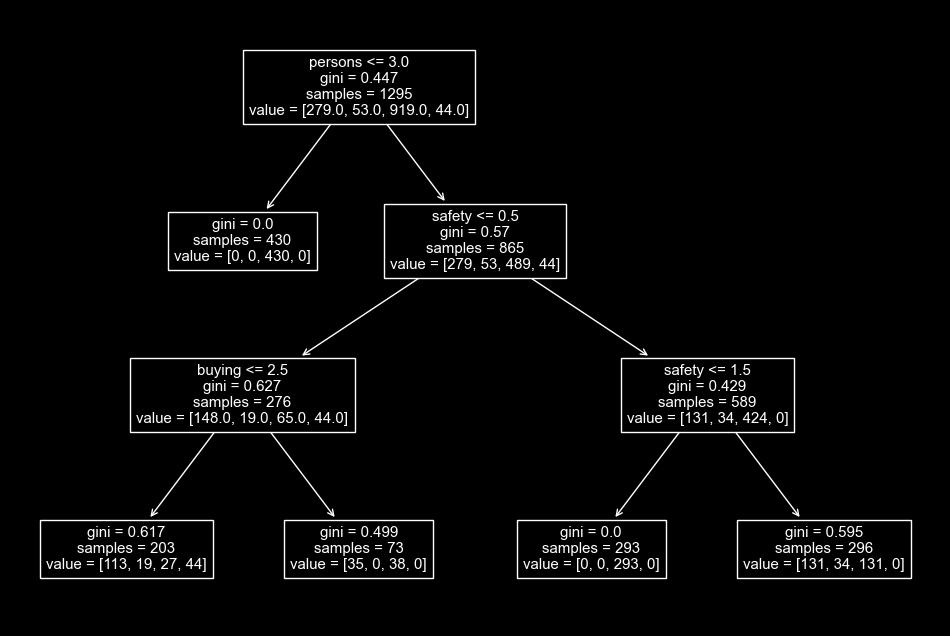

In [31]:
plt.figure(figsize=(12,8))

from sklearn.tree import plot_tree

columns_name = categorical_cols + numerical_cols

plot_tree(tree_model.fit(X_train_transformed, y_train), feature_names=columns_name)

In [32]:
# Hyperparameter Tuning

param = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 7, 9, 11, None],
    "splitter": ["best", "random"],
    "max_features": ["sqrt", "log2", None],
}

In [34]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param,
    cv=5,
    scoring="accuracy",
)

In [35]:
import warnings
warnings.filterwarnings("ignore")

grid.fit(X_train_transformed, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 5, 7, 9, 11, None],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [36]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 11,
 'max_features': None,
 'splitter': 'best'}

In [37]:
y_pred = grid.predict(X_test_transformed)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         acc       0.97      0.96      0.97       105
        good       0.76      0.81      0.79        16
       unacc       1.00      1.00      1.00       290
       vgood       0.90      0.86      0.88        21

    accuracy                           0.98       432
   macro avg       0.91      0.91      0.91       432
weighted avg       0.98      0.98      0.98       432

Confusion Matrix:
 [[101   2   1   1]
 [  2  13   0   1]
 [  0   0 290   0]
 [  1   2   0  18]]
Accuracy Score: 0.9768518518518519


In [41]:
tree_new = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=11,
    splitter="best",
    max_features=None,
    random_state=42,
)

tree_new.fit(X_train_transformed, y_train)
y_pred_new = tree_new.predict(X_test_transformed)

print("Classification Report:\n", classification_report(y_test, y_pred_new))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))
print("Accuracy Score:", accuracy_score(y_test, y_pred_new))

Classification Report:
               precision    recall  f1-score   support

         acc       0.97      0.96      0.97       105
        good       0.76      0.81      0.79        16
       unacc       1.00      1.00      1.00       290
       vgood       0.90      0.86      0.88        21

    accuracy                           0.98       432
   macro avg       0.91      0.91      0.91       432
weighted avg       0.98      0.98      0.98       432

Confusion Matrix:
 [[101   2   1   1]
 [  2  13   0   1]
 [  0   0 290   0]
 [  1   2   0  18]]
Accuracy Score: 0.9768518518518519


[Text(0.53076171875, 0.9583333333333334, 'persons <= 3.0\nentropy = 1.183\nsamples = 1295\nvalue = [279.0, 53.0, 919.0, 44.0]'),
 Text(0.51513671875, 0.875, 'entropy = 0.0\nsamples = 430\nvalue = [0, 0, 430, 0]'),
 Text(0.54638671875, 0.875, 'safety <= 0.5\nentropy = 1.457\nsamples = 865\nvalue = [279, 53, 489, 44]'),
 Text(0.265625, 0.7916666666666666, 'buying <= 2.5\nentropy = 1.662\nsamples = 276\nvalue = [148.0, 19.0, 65.0, 44.0]'),
 Text(0.140625, 0.7083333333333334, 'buying <= 0.5\nentropy = 1.656\nsamples = 203\nvalue = [113, 19, 27, 44]'),
 Text(0.0625, 0.625, 'maint <= 2.5\nentropy = 0.858\nsamples = 71\nvalue = [51, 0, 20, 0]'),
 Text(0.046875, 0.5416666666666666, 'doors <= 2.5\nentropy = 0.31\nsamples = 54\nvalue = [51, 0, 3, 0]'),
 Text(0.03125, 0.4583333333333333, 'lug_boot <= 1.5\nentropy = 0.696\nsamples = 16\nvalue = [13, 0, 3, 0]'),
 Text(0.015625, 0.375, 'entropy = 0.0\nsamples = 10\nvalue = [10, 0, 0, 0]'),
 Text(0.046875, 0.375, 'persons <= 4.5\nentropy = 1.0\nsampl

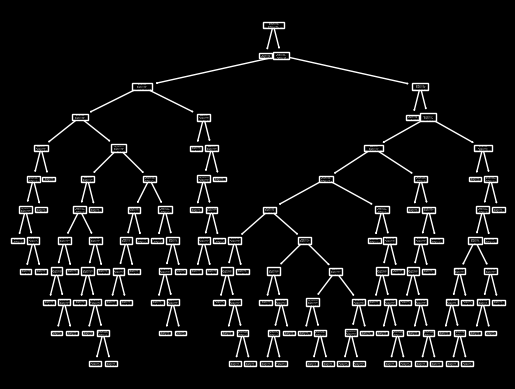

In [40]:
plot_tree(tree_new.fit(X_train_transformed, y_train), feature_names=columns_name)